**Jack Dai**

CS 252: Mathematical Data Analysis and Visualization

# Lab 5 | Truncated Singular Value Decomposition

This week you will use the truncated singular value decomposition (SVD) to recommend food recipes that [Food.com](https://www.food.com) users have not rated before online. We will be using the Food.com recipe dataset, which has been modified for the purposes of today's lab. The recipe dataset comes from the following paper:

**Generating Personalized Recipes from Historical User Preferences**<br/>
Bodhisattwa Prasad Majumder*, Shuyang Li*, Jianmo Ni, Julian McAuley<br/>
*EMNLP*, 2019<br/>
[link](https://cseweb.ucsd.edu/~jmcauley/pdfs/emnlp19c.pdf) 

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import TruncatedSVD

np.set_printoptions(suppress=True, precision=5, legacy='1.25')

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.figsize': [6,6]})

## Task L1: The Recipe dataset

The CSV file `recipe_user_item.csv` contains the user-item matrix for the original Food.com recipe dataset.
- Each **row** corresponds to a unique Food.com user
- Each **column** corresponds to a unique recipe on Food.com.
- Each **entry** in the user-item matrix is the star rating a user (row) gave for a particular recipe (column). The star ratings of a recipe are in 0.5 increments, where `0.5` is worse and `5` is best. 

**Possible star ratings**: [`0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5`]

**Note:** Because of the large number of recipes (`2160`), each user has rated only a small subset of them. Recipes that have not been rated by users have entries of `0`.

We will refer to a user by their row number (`userId`, int: 0, 1, 2, ...) and to a recipe by its column number (`recipeId`, int: 0, 1, 2, ...). The actual string recipe names will be imported later below. 

### L1a. Load the Recipe dataset

1. Use pandas, np.genfromtxt or np.loadtxt to load in the Recipe dataset user-item matrix `recipe_user_item.csv` below. Make sure the first row is skipped (*important for some of CSV loading methods*), since it just contains the `recipeId` int code (ascending column number).
2. Print out the shape. It should be `(2745, 2160)`.
3. Printing out the 1st 10 ratings in the 1st row should yield all `0`s.

In [8]:
# YOUR CODE HERE
df = pd.read_csv('data/recipe_user_item.csv')
print(df.shape)
print(df.iloc[0,:10].to_numpy())

(2745, 2160)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### L1b. Center the user-item matrix

Since we will be computing the SVD of the user-item matrix to predict how users will rate recipes they have not rated before, we should center the user-item matrix.

1. Assign the mean ratings ACROSS users to a variable named `ui_means`. The shape of `ui_means` should be `(2160,)`
2. Center the user-item matrix using each user's means. Assign this to new variable (i.e. do not replace your user-item matrix).
3. Print the 1st 3 values of the first row of the centered user-item matrix. They should be `[-0.04481, -0.04991, -0.07614]`

In [9]:
# YOUR CODE HERE
ui_means = np.mean(df, axis=0)
print(ui_means.shape)
ui_centered = df-ui_means
print(ui_centered.iloc[0, :3].to_numpy())

(2160,)
[-0.04481 -0.04991 -0.07614]


### L1c. Compute the SVD of the user-item matrix

1. Use the [Scikit Learn's TruncatedSVD class](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) to create an `TruncatedSVD` object with `5` basis vectors (aka "components") and use the `'arpack'` algorithm.
   1. Use one of the methods from the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD.fit_transform) to fit the SVD to the centered user-item matrix and obtain the dimensionality reduced version with shape `(N, K)` where `K` is the number of top basis vectors preserved. *This should take a few seconds to run.*
   2. Use another method to take the dimensionality reduced matrix with `K=5` basis vectors to reconstruct the user-item matrix. The reconstructed user-item matrix should have the same shape as the original user-item data matrix `(N, M) = (2745, 2160)`.
2. Use `ui_means` to undo the centering of the SVD-reconstructed user-item matrix of predicted ratings.
3. [Clip](https://numpy.org/doc/stable/reference/generated/numpy.clip.html#numpy.clip) ratings to the valid range (i.e. any value less than 0 should be set to 0, and value above 5 should be set to 5). Print out the sum of all the ratings after clipping, it should be `~461978.57`
4. Print the shape of your reconstructed user-item matrix. It should be `(2745, 2160)`.

In [10]:
# YOUR CODE HERE
svd = TruncatedSVD(n_components=5, algorithm='arpack', random_state=0)
ui_reduced = svd.fit_transform(ui_centered)
ui_reconstructed = svd.inverse_transform(ui_reduced)

ui_pred = np.clip(ui_reconstructed + ui_means.to_numpy(), 0, 5)
print(np.sum(ui_pred))
print(ui_pred.shape)

461978.5702787265
(2745, 2160)


5. Use [plt.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot the predicted ratings for user whose index is `20`. There should be a peak for recipe 460 (predicted rating of 5). Label your axes and provide a title.

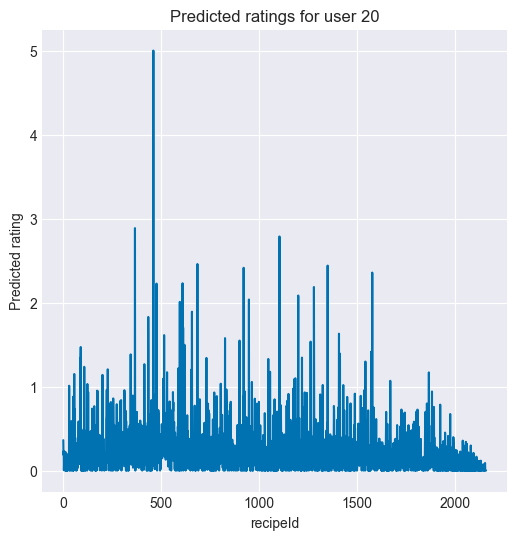

In [11]:
# YOUR CODE HERE
plt.figure()
plt.plot(ui_pred[20])
plt.xlabel('recipeId')
plt.ylabel('Predicted rating')
plt.title('Predicted ratings for user 20')
plt.show()

## Task L2: Practice new NumPy functions

### L2a. Find indices of nonzero items in an array

Use [np.nonzero](https://numpy.org/doc/stable/reference/generated/numpy.nonzero.html#numpy-nonzero) to print out the indices of the nonzero items in the below array. You should get `[0 1 4 6 8]`. Make sure that the output is a regular ndarray with shape `(blah,)`, NOT a tuple.

In [12]:
arr_2a = np.array([1, 9, 0, 0, 3, 0, 2, 0, 8])  # KEEP ME

In [16]:
# YOUR CODE HERE
nonzero_idxs = np.nonzero(arr_2a)[0]
print(nonzero_idxs)

[0 1 4 6 8]


### L2b. Find indices of zero valued items in an array

Use [np.where](https://numpy.org/doc/stable/reference/generated/numpy.where.html) to find and print out the indices of all the 0s in the below array. You should get `[2 3 5 7]`. Make sure that the output is a regular ndarray with shape `(blah,)`, NOT a tuple.

In [13]:
arr_2b = np.array([1, 9, 0, 0, 3, 0, 2, 0, 8])  # KEEP ME

In [17]:
# YOUR CODE HERE
zero_idxs = np.where(arr_2b == 0)[0]
print(zero_idxs)

[2 3 5 7]


## Task L3: Determine top-k recommended recipes not rated by a selected user

The goal is to recommend `k` (e.g. 10) recipes that have not been rated by the selected user on Food.com that garner the top-`k` predicted ratings in the SVD-recovered user-item matrix.

**NOTE:** You will be reusing the code that you write here for on the Project.

In [14]:
curr_user_id = 4  # UserId to whom we are recommending recipes
top_k_rated = 10  # How many top recipes predictions we want to obtain (e.g. top 10)

Run the following code that loads in a Python dictionary that maps the `recipeId`/column number (int coded) to the real human-readable recipe name (string). 

In [15]:
# Run the following provided code to load in the recipeId (key) to recipe name (value) dictionary recipeNameDict
fp = open('data/recipe_name_dict.pkl', 'rb')
recipeNameDict = pickle.load(fp)
fp.close()

1. Use indexing to extract from the user-item matrix all the ratings of the selected current user (i.e. a row) set above. Printing indices 200 to 210 should yield<br>`[0. 0. 0. 0. 5. 0. 0. 0. 5. 0.]`

In [18]:
# YOUR CODE HERE
curr_user_ratings = df.iloc[curr_user_id].to_numpy()
print(curr_user_ratings[200:210])

[0. 0. 0. 0. 5. 0. 0. 0. 5. 0.]


2. Use `np.where` to determine the indices of the recipes that have been NOT rated by the current user (i.e. those that ARE zero). For the test user, there are `2144` unrated recipes.<br><br>`print(unrated_recipeIds[500:505])` should yield `[508 509 510 511 512]`.

In [19]:
# YOUR CODE HERE
unrated_recipeIds = np.where(curr_user_ratings == 0)[0]
print(unrated_recipeIds.size)
print(unrated_recipeIds[500:505])

2144
[508 509 510 511 512]


3. Use `np.ones` or a similar function to create a 1D ndarray that has length equal to the number of recipes the selected user has NOT rated and all entries are the SAME `userId`, stored as an `int` dtype. For example, for user `4`, the array would look like<br>`[4, 4, 4, ..., 4]`<br>For user `4` this array should have shape `(2144,)`.
   1. Make sure the dtype is `int` (each value should be `4` rather than `4.0`). This is important because the array will be used for indexing and NumPy does not allow us to use float indices.

**NOTE:** Since you will be reusing this code on the project, do not hardcode shapes.

In [20]:
# YOUR CODE HERE
unrated_userIds = np.ones(unrated_recipeIds.shape[0], dtype=int) * curr_user_id
print(unrated_userIds.shape)
print(unrated_userIds.dtype)

(2144,)
int64


4. Use your work from 2) and 3) to make a 1D array of the **predicted** ratings extracted from the **SVD-reconstructed user-item matrix** of recipes that the selected user has NOT rated from Task L1c (shape should be `(2144,)`). *It is totally fine to use a loop for this!*<br>The 1st 5 predicted ratings (*from the beginning of the array, not top-k*) for unrated recipes for the curr user `4` should be<br>`[0.02168 0.01305 0.04386 0.01146 0.07957]`


In [21]:
# YOUR CODE HERE
unrated_pred_ratings = ui_pred[unrated_userIds, unrated_recipeIds]
print(unrated_pred_ratings.shape)
print(unrated_pred_ratings[:5])

(2144,)
[0.02168 0.01305 0.04386 0.01146 0.07957]


5. Now we want to come up with a list of the **recipe IDs** that are UNRATED by the current user, ordered HIGH→LOW based on our predicted ratings (*from part 4 above*). In other words, we want to put UNRATED recipe IDs for the current user with the HIGHEST predicted rating EARLY in the list and those with the LOWEST rating should come LATER in the list. The unrated recipe indices/`recipeId`s should come from part 2 above. **Note:** we want the RECIPE IDS (ints) of the recipes that produced the greatest predictions here.<br/><br/>For the test user these should be below these recipe IDs should be:<br/>`[ 948 1325 1104 1215 1107  837  804  992  366  434]`. 


*Hint: Use [this function](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html#numpy-argsort) and indexing. Additionally, recall that the linked function provides indices that would sort the array low-to-high by default, which is not exactly what you want...*

In [22]:
# YOUR CODE HERE
sorted_unrated_idx = np.argsort(unrated_pred_ratings)[::-1]
sorted_unrated_recipeIds = unrated_recipeIds[sorted_unrated_idx]

top_k_recipeIds = sorted_unrated_recipeIds[:top_k_rated]
print(top_k_recipeIds)

[ 948 1325 1104 1215 1107  837  804  992  366  434]


6. Create a list of the STRING names of the top-k predicted recipes for the selected user. This should make use of `recipeNameDict` (*loaded at the beginning of this Task*) to look up the recipe string names and the `recipeId`s of the top predicted recipes from part 5.<br>*A loop is totally fine here!*<br/><br/>
7. Print the top-k recipe names for the selected user (*use k=10 here*).<br>*A loop is totally fine here!*<br/><br/>For user `4`, the 1st top rated recipes should be:<br>*roasted brussels sprouts*<br>and the 10th top rated recipe should be:<br>*so it s bekah s pulled pork now*.

In [23]:
# YOUR CODE HERE
top_k_recipe_names = []
for recipe_id in top_k_recipeIds:
    top_k_recipe_names.append(recipeNameDict[int(recipe_id)])

for i, recipe_name in enumerate(top_k_recipe_names, start=1):
    print(f"{i}. {recipe_name}")

1. roasted brussels sprouts
2. greek potatoes  oven roasted and delicious
3. japanese mum s chicken
4. pan release  professional pan coating  better than pam spray
5. kittencal s italian melt in your mouth meatballs
6. oven fried eggplant  aubergine
7. uncle bill s microwave potato chips
8. tzatziki
9. jo mama s world famous spaghetti
10. so it s bekah s pulled pork now


### L3d. Questions

**Question:** Have some fun and obtain recommendations for a few different users! Copy-paste some results below to document your exploration.

**Answer:** I tried several users and the top recommendations were different but there were some popular repeats (for example, *to die for crock pot roast* appeared for multiple users). Sample results:

- **User 0 (top 5):**
  1. to die for crock pot roast
  2. crock pot chicken with black beans   cream cheese
  3. banana banana bread
  4. reeses squares   5 ingredients   no bake  reese s
  5. uncle bill s microwave potato chips

- **User 20 (top 5):**
  1. to die for crock pot roast
  2. creamy cajun chicken pasta
  3. crock pot chicken with black beans   cream cheese
  4. grilled cheese  diner style
  5. crock pot whole chicken

- **User 500 (top 5):**
  1. roasted brussels sprouts
  2. greek potatoes  oven roasted and delicious
  3. so it s bekah s pulled pork now
  4. roasted cauliflower   16 roasted cloves of garlic
  5. japanese mum s chicken

The recommendations look reasonable: some are broadly popular recipes, while others vary by user preference profile.

## Turn in your lab

Follow the usual submission format and submit your lab on Google Classroom.